# Task 3: Handwritten Character Recognition using CNN

**Objective:** Identify handwritten digits using deep learning.

**Dataset:** MNIST  
**Model:** Convolutional Neural Network (CNN)  
**Framework:** PyTorch

This notebook follows the same overall workflow as the previous MNIST project, but uses a **CNN**, which matches the internship Task 3 requirement.

In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


In [2]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Download and Explore the MNIST Dataset

In [3]:
# Download training dataset
dataset = MNIST(
    root="data/",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = MNIST(
    root="data/",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print("Training samples:", len(dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.44MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 95.1kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.35MB/s]

Training samples: 60000
Test samples: 10000


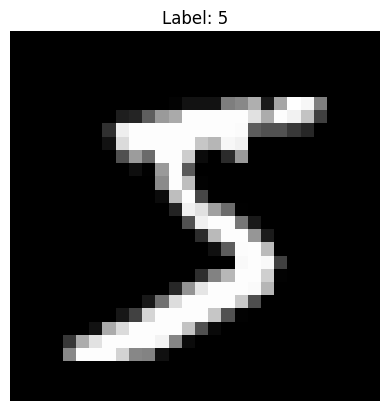

Image shape: torch.Size([1, 28, 28])
Label: 5


In [4]:
# Display a sample image
img, label = dataset[0]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.title(f"Label: {label}")
plt.show()

print("Image shape:", img.shape)
print("Label:", label)

## 2. Training and Validation Split

In [5]:
# Reproducible train/validation split
torch.manual_seed(42)

val_size = 10000
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Validation samples: 10000
Test samples: 10000


In [6]:
# Hyperparameters
batch_size = 100
learning_rate = 0.001
epochs = 20

print("Batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Epochs:", epochs)

Batch size: 100
Learning rate: 0.001
Epochs: 20


In [7]:
# Data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=200,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


## 3. Build the Convolutional Neural Network

In [8]:
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 64 x 7 x 7
            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, xb):
        return self.network(xb)


model = MnistCNN().to(device)
print(model)

MnistCNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [9]:
# Check the model output shape
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([100, 1, 28, 28])
Output shape: torch.Size([100, 10])


## 4. Loss Function, Optimizer and Accuracy

In [10]:
loss_fn = F.cross_entropy

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return (preds == labels).float().mean().item()

print("Loss function: Cross Entropy")
print("Optimizer: Adam")
print("Learning rate:", learning_rate)

Loss function: Cross Entropy
Optimizer: Adam
Learning rate: 0.001


## 5. Training and Evaluation Functions

In [11]:
def evaluate(model, data_loader, loss_fn):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            total_correct += (outputs.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, total_correct / total

In [12]:
def fit(epochs, model, loss_fn, optimizer, train_loader, val_loader):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_correct = 0
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            running_correct += (outputs.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total

        val_loss, val_acc = evaluate(model, val_loader, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Accuracy: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Accuracy: {val_acc:.4f}"
        )

    return history

## 6. Train the CNN

In [ ]:
history = fit(
    epochs,
    model,
    loss_fn,
    optimizer,
    train_loader,
    val_loader
)

Epoch [1/20], Train Loss: 0.2335, Train Accuracy: 0.9285, Val Loss: 0.0797, Val Accuracy: 0.9761
Epoch [2/20], Train Loss: 0.0600, Train Accuracy: 0.9818, Val Loss: 0.0723, Val Accuracy: 0.9781
Epoch [3/20], Train Loss: 0.0426, Train Accuracy: 0.9868, Val Loss: 0.0572, Val Accuracy: 0.9828
Epoch [4/20], Train Loss: 0.0300, Train Accuracy: 0.9906, Val Loss: 0.0642, Val Accuracy: 0.9814
Epoch [5/20], Train Loss: 0.0242, Train Accuracy: 0.9923, Val Loss: 0.0417, Val Accuracy: 0.9875
Epoch [6/20], Train Loss: 0.0188, Train Accuracy: 0.9938, Val Loss: 0.0438, Val Accuracy: 0.9878
Epoch [7/20], Train Loss: 0.0154, Train Accuracy: 0.9949, Val Loss: 0.0546, Val Accuracy: 0.9854
Epoch [8/20], Train Loss: 0.0119, Train Accuracy: 0.9963, Val Loss: 0.0407, Val Accuracy: 0.9886
Epoch [9/20], Train Loss: 0.0113, Train Accuracy: 0.9965, Val Loss: 0.0422, Val Accuracy: 0.9900
Epoch [10/20], Train Loss: 0.0092, Train Accuracy: 0.9969, Val Loss: 0.0454, Val Accuracy: 0.9884
Epoch [11/20], Train Loss: 0.

## 7. Plot Accuracy

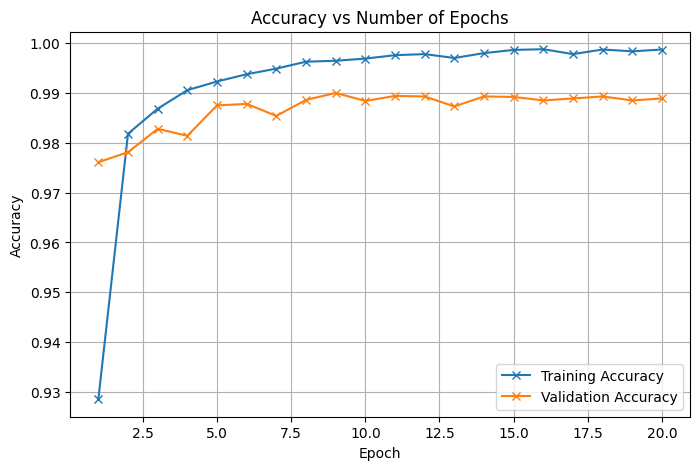

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_accuracy"], "-x", label="Training Accuracy")
plt.plot(epochs_range, history["val_accuracy"], "-x", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 8. Plot Loss

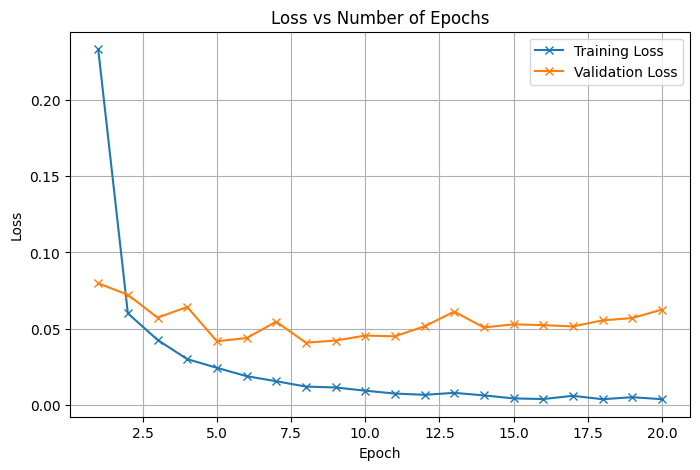

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], "-x", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], "-x", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Number of Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 9. Final Validation Results

In [ ]:
val_loss = history["val_loss"][-1]
val_acc = history["val_accuracy"][-1]

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_acc, 4))
print("Validation Accuracy (%):", round(val_acc * 100, 2))

Validation Loss: 0.0625
Validation Accuracy: 0.9889
Validation Accuracy (%): 98.89


## 10. Test Individual Images

In [ ]:
def predict_image(img, model):
    model.eval()

    with torch.no_grad():
        xb = img.unsqueeze(0).to(device)
        outputs = model(xb)
        prediction = outputs.argmax(dim=1).item()

    return prediction

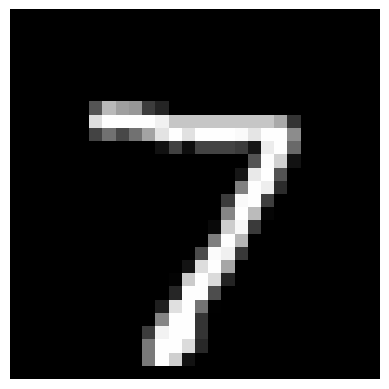

Label: 7 , Predicted: 7


In [ ]:
# Test example 1
img, label = test_dataset[0]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.show()

print("Label:", label, ", Predicted:", predict_image(img, model))

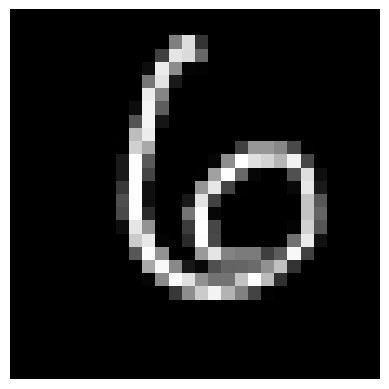

Label: 6 , Predicted: 6


In [ ]:
# Test example 2
img, label = test_dataset[100]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.show()

print("Label:", label, ", Predicted:", predict_image(img, model))

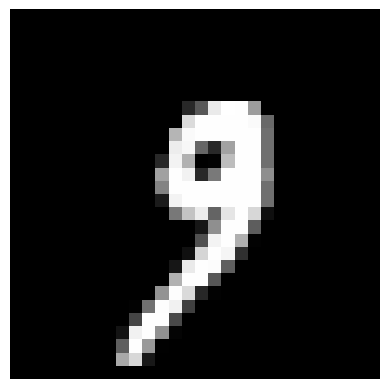

Label: 9 , Predicted: 9


In [ ]:
# Test example 3
img, label = test_dataset[1000]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.show()

print("Label:", label, ", Predicted:", predict_image(img, model))

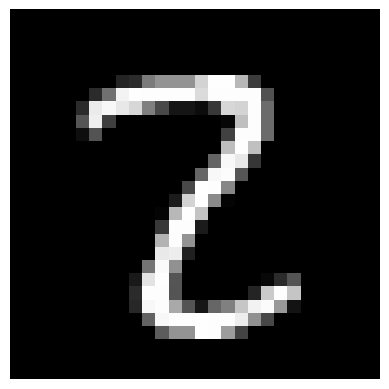

Label: 2 , Predicted: 2


In [ ]:
# Test example 4
img, label = test_dataset[1839]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.show()

print("Label:", label, ", Predicted:", predict_image(img, model))

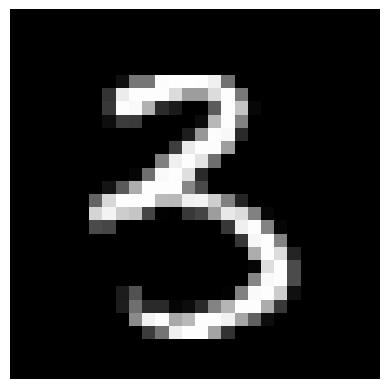

Label: 3 , Predicted: 3


In [ ]:
# Test example 5
img, label = test_dataset[5000]

plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.show()

print("Label:", label, ", Predicted:", predict_image(img, model))

## 11. Evaluate on the Complete Test Set

In [ ]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    loss_fn
)

print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_acc))
print("Test Accuracy: {:.2f}%".format(test_acc * 100))

Test Loss: 0.0470
Test Accuracy: 0.9903
Test Accuracy: 99.03%


## 12. Save the Model and Experiment Details

In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),

    "hyperparameters": {
        "optimizer": "Adam",
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "architecture": "CNN"
    },

    "metrics": {
        "validation_loss": val_loss,
        "validation_accuracy": val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    }
}

torch.save(checkpoint, "mnist-cnn.pth")

print("Model and experiment details saved to mnist-cnn.pth")

Model and experiment details saved to mnist-cnn.pth


In [ ]:
# Load the saved checkpoint
checkpoint = torch.load("mnist-cnn.pth", map_location=device)

model2 = MnistCNN().to(device)
model2.load_state_dict(checkpoint["model_state_dict"])

print("Model loaded successfully.")

print("\nHyperparameters:")
for key, value in checkpoint["hyperparameters"].items():
    print(key, ":", value)

print("\nMetrics:")
for key, value in checkpoint["metrics"].items():
    print(key, ":", value)

Model loaded successfully.

Hyperparameters:
optimizer : Adam
learning_rate : 0.001
batch_size : 100
epochs : 20
architecture : CNN

Metrics:
validation_loss : 0.06248855728567833
validation_accuracy : 0.9889
test_loss : 0.04698145674443822
test_accuracy : 0.9903


## Conclusion

The project implements **handwritten digit recognition using a Convolutional Neural Network (CNN)** on the MNIST dataset.

The final validation and test accuracy are generated automatically when the notebook is run. This notebook does **not require Jovian**.